# Kkcalc for S K-edge NEXAFS

## Setup

### Imports

In [1]:
# Imports:
import sys
import pathlib
import re
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import xarray as xr
import pandas as pd
import dask.array as da
# import kkcalc
# from kkcalc import data
# from kkcalc import kk
from kkcalc.models import *
from kkcalc import stoichiometry
import xraydb
from scipy import optimize
from tqdm.auto import tqdm

# nexafsFxnsPath = basePath.joinpath('misc_older_work/nexafs_analysis')
# sys.path.append(str(nexafsFxnsPath))
# import nexafs_fxns as nf  # custom nexafs functions used throughout this notebook

### Define paths/objects

In [2]:
basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite')
nfZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/fl_nexafs_zarrs')
molZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/mol_nexafs_zarrs')
lpZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_normal/lamella_vs_energy_zarrs')

molASFsZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/mol_asfs_zarrs')
molf1f2ZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/mol_f1f2_zarrs')
moldeltabetaZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/mol_deltabeta_zarrs')

scratchPath = basePath.joinpath('local_data/kkcalc_scratch')
nfZarrsPath.exists()

True

In [3]:
molf1f2ZarrsPath.exists()

True

## NEXAFS -> Atomic Scattering Factors (kkcalc)

### Load NEXAF data

In [4]:
# Define path to zarr
# nfZarrPath = sorted(nfZarrsPath.glob('*.zarr'))[0]
nfZarrPath = sorted(molZarrsPath.glob('*.zarr'))[0]
nfZarrPath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/trexs_nexafs_2024C3/waxs_all/mol_nexafs_zarrs/PM6_5CN-CF_mol_nexafs_v1.zarr')

In [5]:
# Load zarr into xarray
# nf_DA = xr.open_zarr(nfZarrPath)['fl_nexafs'].compute()
nf_DA = xr.open_zarr(nfZarrPath)['extrapolated_nexafs'].compute()
nf_DA

<xarray.DataArray 'extrapolated_nexafs' (theta: 100, energy: 45)> Size: 36kB
array([[0.13824851, 0.04938506, 0.02591568, ..., 1.19977449, 1.0253999 ,
        0.9746001 ],
       [0.13804999, 0.04955433, 0.02596319, ..., 1.20111717, 1.02620912,
        0.97379088],
       [0.13785147, 0.0497236 , 0.0260107 , ..., 1.20245984, 1.02701835,
        0.97298165],
       ...,
       [0.11899183, 0.06580414, 0.03052438, ..., 1.33001418, 1.10389471,
        0.89610529],
       [0.1187933 , 0.06597341, 0.03057189, ..., 1.33135686, 1.10470393,
        0.89529607],
       [0.11859478, 0.06614268, 0.03061941, ..., 1.33269954, 1.10551316,
        0.89448684]])
Coordinates:
    cos_sq_theta  (theta) float64 800B -0.4253 -0.4097 -0.3942 ... 1.1 1.115
  * energy        (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
    sample_ID     <U5 20B 'SiN-4'
  * theta         (theta) float64 800B 90.0 89.09 88.18 ... 1.818 0.9091 0.0
Attributes:
    unit:     a.u.

In [6]:
# Initalize dictionaries for sample names (for titles & saving files)
sn = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7 CF + 0.0% CN',
    'SiN-2': 'PM7 CF + 5.0% CN',
    'SiN-3': 'PM6 CF + 0.0% CN',
    'SiN-4': 'PM6 CF + 5.0% CN',
    'SiN-5': 'PM7 CF + 1.0% CN',
    'SiN-6': 'PM7 CF + 0.5% CN',
    'SiN-7': 'PM6 CF + 1.0% CN',
    'SiN-8': 'PM6 CF + 0.5% CN',    
}

sn_id = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7_CF',
    'SiN-2': 'PM7_5CN-CF',
    'SiN-3': 'PM6_CF',
    'SiN-4': 'PM6_5CN-CF',
    'SiN-5': 'PM7_1CN-CF',
    'SiN-6': 'PM7_p5CN-CF',
    'SiN-7': 'PM6_1CN-CF',
    'SiN-8': 'PM6_p5CN-CF',
}

### Run kkcalc for atomic scattering factors

(43, 2)
(43, 2)


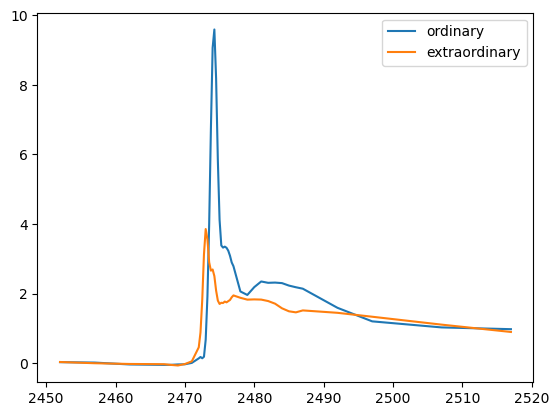

In [7]:
%matplotlib inline
plt.close('all')

e_slice = slice(2450,2520)

# Put into numpy array (1st column energy, 2nd column nexafs) and check data
ord_np_nf = np.array([nf_DA.sel(theta=90, method='nearest').sel(energy=e_slice).energy,
                      nf_DA.sel(theta=90, method='nearest').sel(energy=e_slice).data]).T

ext_np_nf = np.array([nf_DA.sel(theta=0, method='nearest').sel(energy=e_slice).energy,
                      nf_DA.sel(theta=0, method='nearest').sel(energy=e_slice).data]).T
# np_nf = np.array([nf_DA.sel(energy=e_slice).energy,nf_DA.sel(energy=e_slice).sel(sample_ID='SiN-2').data]).T
print(ord_np_nf.shape)
print(ext_np_nf.shape)

plt.plot(ord_np_nf[:,0], ord_np_nf[:,1], label='ordinary')
plt.plot(ext_np_nf[:,0], ext_np_nf[:,1], label='extraordinary')
plt.legend()
plt.show()


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

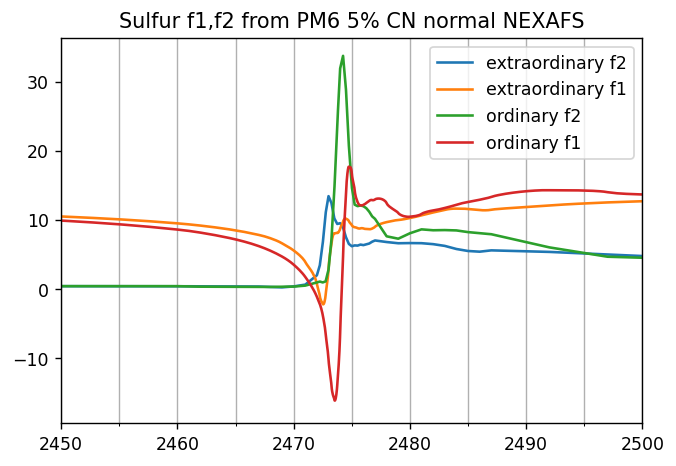

In [102]:
%matplotlib inline
plt.close('all')

##### Copied KKcalc v2 format:

PM6 = "C68H76F2O2S8"
# stoich = stoichiometry(PM6)
stoich=stoichiometry('S')
# stoich=stoichiometry('C5S1')

# PM7 = "C68H76Cl2O2S8"
# stoich = stoichiometry(PM7)

asp_db = asp_db_im(stoich)

# nf_orients = ['ordinary', 'extraordinary']
# np_nfs = [ord_np_nf, ext_np_nf]

nf_orients = ['extraordinary', 'ordinary']
np_nfs = [ext_np_nf, ord_np_nf]

fig, ax = plt.subplots()
fig.set(size_inches=(6,4), dpi=125)

mol_ordext_f1f2_DS = xr.Dataset()

for nf_orient, np_nf in zip(nf_orients, np_nfs):
    # Create the atomic scattering factors from NEXAFS data
    asf = asf_im.from_NEXAFS(energies = np_nf[:,0], 
                             NEXAFS = np_nf[:,1],
                             stoichiometry=stoich)
    
    # Combine the data with the database into polynomials
    imag = asp_db_im_extended(
        data_asf=asf,
        database=asp_db,
        merge_domain=(2460, 2510)
    )
    
    # Use the KK transform on two sets of objects, the extended data, and the raw data.
    # for j, asp_obj in enumerate([imag, asf.to_ASP()]):
    for j, asp_obj in enumerate([imag]):
    
        past_points = []
        
        for i in tqdm(range(0,5)):
        
        # Perform the transfom with i improvement iterations
            extended_real = asp_obj.kk_transform(
                relativistic_correction=stoich.relativistic_correction,
                tolerance=0.01,
                max_iter=i)
            
            # Convert the imaginary coefs to imaginary factors
            imag_factors = imag.eval_asf(extended_real.energies)
            
            # Find new points
            new_energies = np.setdiff1d(extended_real.energies, past_points, assume_unique=True)
            new_points = np.array([i for i, e in enumerate(extended_real.energies) if e in new_energies])
            past_points = np.concatenate((past_points, new_energies))
    
    #### End of copy!
    
    # fp_offset = -16  # THIS IS BECAUSE f1 = f0 + f' !!!, so subtract f0 (sulfur f0 = 16)

    # Collect data, make into dataarray and append into dataset but also plot below
    # PM6_fp_fpp_arr = np.array([extended_real.energies, imag_factors, extended_real.factors+fp_offset]).T
    PM6_f1_f2_arr = np.array([extended_real.energies, imag_factors, extended_real.factors]).T

    specified_energies = np.array([2442.  , 2447.  , 2452.  , 2457.  , 2462.  , 2467.  , 2468.  ,
                                   2469.  , 2470.  , 2471.  , 2472.  , 2472.25, 2472.5 , 2472.75,
                                   2473.  , 2473.25, 2473.5 , 2473.75, 2474.  , 2474.25, 2474.5 ,
                                   2474.75, 2475.  , 2475.25, 2475.5 , 2475.75, 2476.  , 2476.25,
                                   2476.5 , 2476.75, 2477.  , 2478.  , 2479.  , 2480.  , 2481.  ,
                                   2482.  , 2483.  , 2484.  , 2485.  , 2486.  , 2487.  , 2492.  ,
                                   2497.  , 2507.  , 2517.  ])
    
    f2_DA = xr.DataArray(data=imag_factors, dims=['energy'], coords={'energy':extended_real.energies})
    f2_DA = f2_DA.interp({'energy':specified_energies})
    f1_DA = xr.DataArray(data=extended_real.factors, dims=['energy'], coords={'energy':extended_real.energies})
    f1_DA = f1_DA.interp({'energy':specified_energies})

    mol_ordext_f1f2_DS[f"S_{nf_orient}_f2"] = f2_DA
    mol_ordext_f1f2_DS[f"S_{nf_orient}_f1"] = f1_DA
    
    
    e_min = 2450
    e_max = 2500
    
    # e_min = 2470
    # e_max = 2480
    
    # fig, ax = plt.subplots()
    # fig.set(size_inches=(4.5,3), dpi=125)
    
    # ax.plot(PM6_imag_real_arr[:,0], PM6_imag_real_arr[:,1] * 0.1, label="f'': imaginary")
    # ax.plot(PM6_imag_real_arr[:,0], (PM6_imag_real_arr[:,2]-660)*0.1, label="f': real (offset)")
    ax.plot(PM6_f1_f2_arr[:,0], PM6_f1_f2_arr[:,1], label=f"{nf_orient} f2")
    ax.plot(PM6_f1_f2_arr[:,0], PM6_f1_f2_arr[:,2], label=f"{nf_orient} f1")
    ax.set_xlim(e_min, e_max)
    # ax.set_ylim(-5,20)
    # ax.set_ylim(-35,35)
    ax.set_title('Sulfur f1,f2 from PM6 5% CN normal NEXAFS')
    ax.xaxis.grid(visible=True, which='both')
    
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    # ax.xaxis.set_minor_locator(MultipleLocator(1))
    # ax.xaxis.set_major_locator(MultipleLocator(2))
    
    
    ax.legend(loc='upper right')
    
    # savePath = basePath.joinpath('trexs_plots/2024C3/waxs/asf_v3')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(f'PM6_asf_energy{e_min}-{e_max}.png'), dpi=125)
    
plt.show()


In [ ]:
mol_ordext_f1f2_DS

In [14]:
energies = mol_ordext_f1f2_DS.energy.values

# Carbon f components
C_f1 = np.interp(mol_ordext_f1f2_DS.energy.values, asp_db_re(stoichiometry('C')).energies, asp_db_re(stoichiometry('C')).asf)
C_f2 = np.interp(mol_ordext_f1f2_DS.energy.values, asp_db_im(stoichiometry('C')).energies, asp_db_im(stoichiometry('C')).asf)

# Oxygen f components
O_f1 = np.interp(mol_ordext_f1f2_DS.energy.values, asp_db_re(stoichiometry('O')).energies, asp_db_re(stoichiometry('O')).asf)
O_f2 = np.interp(mol_ordext_f1f2_DS.energy.values, asp_db_im(stoichiometry('O')).energies, asp_db_im(stoichiometry('O')).asf)

# Fluorine f components
F_f1 = np.interp(mol_ordext_f1f2_DS.energy.values, asp_db_re(stoichiometry('F')).energies, asp_db_re(stoichiometry('F')).asf)
F_f2 = np.interp(mol_ordext_f1f2_DS.energy.values, asp_db_im(stoichiometry('F')).energies, asp_db_im(stoichiometry('F')).asf)

# Sulfur f components
S_f1 = np.interp(mol_ordext_f1f2_DS.energy.values, PM6_f1_f2_arr[:,0], PM6_f1_f2_arr[:,2])
S_f2 = np.interp(mol_ordext_f1f2_DS.energy.values, PM6_f1_f2_arr[:,0], PM6_f1_f2_arr[:,1])

f_dict = {
    'C': C_f1 + 1j*C_f2,
    'O': O_f1 + 1j*O_f2,
    'F': F_f1 + 1j*F_f2,
    'S': S_f1 + 1j*S_f2
}

In [15]:
# for element in f_dict.keys():
for element in ['C', 'O', 'F']:

    mol_ordext_f1f2_DS[f'{element}_f1'] = xr.DataArray(data=np.real(f_dict[element]), dims=['energy'], coords={'energy':energies})
    mol_ordext_f1f2_DS[f'{element}_f2'] = xr.DataArray(data=np.imag(f_dict[element]), dims=['energy'], coords={'energy':energies})
    
    # plt.plot(energies, np.real(f_dict[element]), label='f1')
    # plt.plot(energies, np.imag(f_dict[element]), label='f2')
    # plt.title(f'{element}')
    # plt.legend()
    # plt.show()

mol_ordext_f1f2_DS

<xarray.Dataset> Size: 4kB
Dimensions:             (energy: 45)
Coordinates:
  * energy              (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
Data variables:
    S_extraordinary_f2  (energy) float64 360B 0.4135 0.4118 ... 4.245 4.006
    S_extraordinary_f1  (energy) float64 360B 10.96 10.68 10.33 ... 12.89 12.73
    S_ordinary_f2       (energy) float64 360B 0.4135 0.4118 ... 4.171 4.006
    S_ordinary_f1       (energy) float64 360B 10.49 10.15 9.695 ... 13.45 13.17
    C_f1                (energy) float64 360B 6.132 6.132 6.132 ... 6.128 6.127
    C_f2                (energy) float64 360B 0.1167 0.1163 ... 0.1108 0.11
    O_f1                (energy) float64 360B 8.273 8.272 8.272 ... 8.266 8.265
    O_f2                (energy) float64 360B 0.37 0.3686 ... 0.3524 0.3498
    F_f1                (energy) float64 360B 9.336 9.335 9.335 ... 9.329 9.328
    F_f2                (energy) float64 360B 0.5687 0.5666 ... 0.5423 0.5384

In [ ]:
# outPath = basePath.joinpath('trexs_plots/2024C3/waxs_all')
# savePath = outPath.joinpath('plotted_f1f2_and_OCs_v1')
# savePath.mkdir(exist_ok=True)
# savePath.exists()

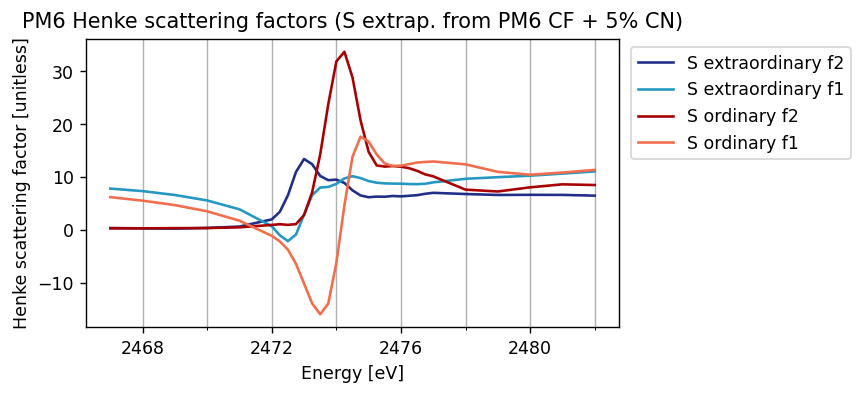

In [103]:
%matplotlib inline
plt.close('all')

fig, ax = plt.subplots(figsize=(5.5,3), dpi=125)

S_f1_colors = plt.cm.OrRd(np.linspace(0.6,0.9,2))
S_f2_colors = plt.cm.YlGnBu(np.linspace(0.6,0.9,2))

other_colors = plt.cm.Greys_r(np.linspace(0.1,0.5,2))

colors_dict = {
    'S_extraordinary_f1': S_f2_colors[0], 
    'S_ordinary_f1': S_f1_colors[0],
    'S_extraordinary_f2': S_f2_colors[1],
    'S_ordinary_f2': S_f1_colors[1],
    'C_f1': other_colors[1],
    'C_f2': other_colors[0],
    'O_f1': other_colors[1],
    'O_f2': other_colors[0],
    'F_f1': other_colors[1],
    'F_f2': other_colors[0],
}

e_slice = slice(2463.5,2482.5)
# e_slice = slice(2450,2520)

for i, DA in enumerate(list(mol_ordext_f1f2_DS.data_vars.values())[:]):
    # if DA.name.split('_')[0] == 'S':
    #     colors = S_f1_colors if DA.name.split('_')[-1]=='f1' else S_f2_colors
    #     DA.sel(energy=slice(2460,2490)).plot(ax=ax, label=DA.name, color=colors[f1])
    # else:
    if 'O' in DA.name:
        DA.sel(energy=e_slice).plot(ax=ax, label=' '.join(DA.name.split('_')), color=colors_dict[DA.name], linestyle='--')
    elif 'F' in DA.name:
        DA.sel(energy=e_slice).plot(ax=ax, label=' '.join(DA.name.split('_')), color=colors_dict[DA.name], linestyle=':')
    else:
        DA.sel(energy=e_slice).plot(ax=ax, label=' '.join(DA.name.split('_')), color=colors_dict[DA.name])


ax.set(ylabel='Henke scattering factor [unitless]', xlabel='Energy [eV]')
ax.set_title('PM6 Henke scattering factors (S extrap. from PM6 CF + 5% CN)')
ax.xaxis.grid(visible=True, which='both')
ax.xaxis.set_major_locator(MultipleLocator(4))
ax.xaxis.set_minor_locator(MultipleLocator(2))
fig.legend(loc='upper right', bbox_to_anchor=(1.25, 0.88))

# # If want to save:
# outPath = basePath.joinpath('trexs_plots/2024C3/waxs_all')
# savePath = outPath.joinpath('plotted_f1f2_and_OCs_v1')
# savePath.mkdir(exist_ok=True)
# fig.savefig(savePath.joinpath(f'PM6_henke_factors'), dpi=125, bbox_inches='tight')

plt.show()


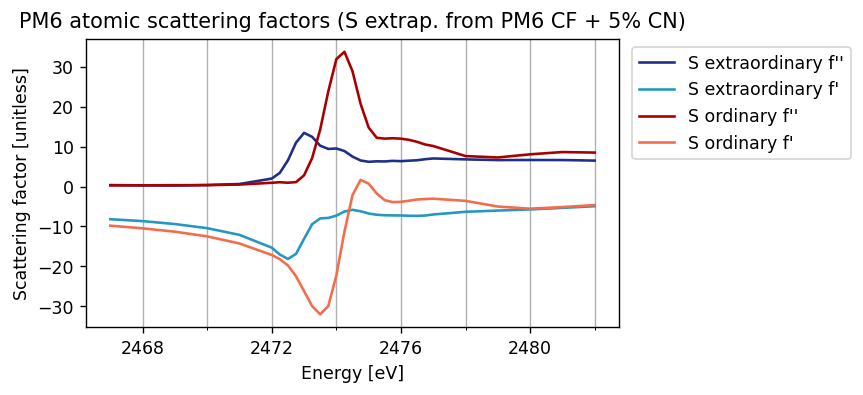

In [108]:
%matplotlib inline
plt.close('all')

fig, ax = plt.subplots(figsize=(5.5,3), dpi=125)

S_f1_colors = plt.cm.OrRd(np.linspace(0.6,0.9,2))
S_f2_colors = plt.cm.YlGnBu(np.linspace(0.6,0.9,2))

other_colors = plt.cm.Greys_r(np.linspace(0.1,0.5,2))

colors_dict = {
    'S_extraordinary_f1': S_f2_colors[0], 
    'S_ordinary_f1': S_f1_colors[0],
    'S_extraordinary_f2': S_f2_colors[1],
    'S_ordinary_f2': S_f1_colors[1],
    'C_f1': other_colors[1],
    'C_f2': other_colors[0],
    'O_f1': other_colors[1],
    'O_f2': other_colors[0],
    'F_f1': other_colors[1],
    'F_f2': other_colors[0],
}

e_slice = slice(2463.5,2482.5)
# e_slice = slice(2450,2520)

for i, DA in enumerate(list(mol_ordext_f1f2_DS.data_vars.values())[:]):
    # if DA.name.split('_')[0] == 'S':
    #     colors = S_f1_colors if DA.name.split('_')[-1]=='f1' else S_f2_colors
    #     DA.sel(energy=slice(2460,2490)).plot(ax=ax, label=DA.name, color=colors[f1])
    # else:
    if 'O' in DA.name:
        DA.sel(energy=e_slice).plot(ax=ax, label=' '.join(DA.name.split('_')), color=colors_dict[DA.name], linestyle='--')
    elif 'F' in DA.name:
        DA.sel(energy=e_slice).plot(ax=ax, label=' '.join(DA.name.split('_')), color=colors_dict[DA.name], linestyle=':')
    else:
        if 'f1' in DA.name:
            DA = DA - 16
            DA.sel(energy=e_slice).plot(ax=ax, label=' '.join(DA.name.split('_')[:-1]+["f'"]), color=colors_dict[DA.name])
        else:
            DA.sel(energy=e_slice).plot(ax=ax, label=' '.join(DA.name.split('_')[:-1]+["f''"]), color=colors_dict[DA.name])


ax.set(ylabel='Scattering factor [unitless]', xlabel='Energy [eV]')
ax.set_title('PM6 atomic scattering factors (S extrap. from PM6 CF + 5% CN)')
ax.xaxis.grid(visible=True, which='both')
ax.xaxis.set_major_locator(MultipleLocator(4))
ax.xaxis.set_minor_locator(MultipleLocator(2))
fig.legend(loc='upper right', bbox_to_anchor=(1.25, 0.88))

# If want to save:
outPath = basePath.joinpath('trexs_plots/2024C3/waxs_all')
savePath = outPath.joinpath('plotted_f1f2_and_OCs_v1')
savePath.mkdir(exist_ok=True)
fig.savefig(savePath.joinpath(f'PM6_S_asf_factors'), dpi=125, bbox_inches='tight')

plt.show()


In [109]:
def f1f2DS_to_deltabetaDS(f1f2DS, 
                          n_atom=1/((2*0.88e-10)**3)):
    """
    Computes delta and beta from a dataset containing variables, with last part of name 'f1' or 'f2' (underscores delimiter)
    According to: delta = (r_e*wavelength^2)/2*pi * f1 * n_atoms, delta = (r_e*wavelength^2)/2*pi * f2 * n_atoms

    Inputs: 
        xarray dataset to convert
        n_atom (float): number of atoms PER VOLUME FRACTION in meters (assume 1 atom per 1.5 angstroms?)

    Returns dataset of same structure as input, with 'delta' or 'beta' now instead of 'f1' or 'f2'
    """
    
    energies = f1f2DS.energy.values
    
    wavelengths = (6.626e-34 * 3e8) / (energies*1.602e-19)  # get wavelenths, in meters
    r_e = 2.8179e-15  # classical electron radius in meters
    # n_atom = 1  # we are setting the number of atoms to 1
    
    deltabetaDS = xr.Dataset()
    for DA in list(mol_ordext_f1f2_DS.data_vars.values())[:]:
        name_terms = DA.name.split('_')
        henke_factor = name_terms[-1]
    
        if henke_factor == 'f1':
            delta_DA = (r_e*(wavelengths**2))/(2*np.pi)*DA*n_atom
            delta_DA_name = '_'.join(name_terms[:-1] + ['delta'])
            deltabetaDS[delta_DA_name] = delta_DA
        elif henke_factor == 'f2':
            beta_DA = (r_e*(wavelengths**2))/(2*np.pi)*DA*n_atom
            beta_DA_name = '_'.join(name_terms[:-1] + ['beta'])
            deltabetaDS[beta_DA_name] = beta_DA

    return deltabetaDS

mol_ordext_deltabeta_DS = f1f2DS_to_deltabetaDS(mol_ordext_f1f2_DS)
mol_ordext_deltabeta_DS

<xarray.Dataset> Size: 2kB
Dimensions:                (energy: 45)
Coordinates:
  * energy                 (energy) float64 360B 2.442e+03 ... 2.517e+03
Data variables:
    S_extraordinary_beta   (energy) float64 360B 8.783e-06 ... 8.009e-05
    S_extraordinary_delta  (energy) float64 360B 0.0002327 ... 0.0002545
    S_ordinary_beta        (energy) float64 360B 8.783e-06 ... 8.009e-05
    S_ordinary_delta       (energy) float64 360B 0.0002228 ... 0.0002634

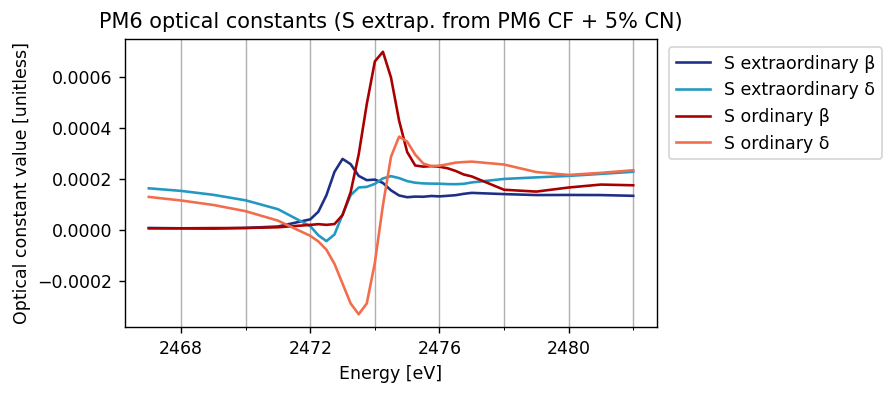

In [111]:
%matplotlib inline
plt.close('all')

fig, ax = plt.subplots(figsize=(5.5,3), dpi=125)

S_f1_colors = plt.cm.OrRd(np.linspace(0.6,0.9,2))
S_f2_colors = plt.cm.YlGnBu(np.linspace(0.6,0.9,2))

other_colors = plt.cm.Greys_r(np.linspace(0.1,0.5,2))

colors_dict = {
    'S_extraordinary_delta': S_f2_colors[0], 
    'S_ordinary_delta': S_f1_colors[0],
    'S_extraordinary_beta': S_f2_colors[1],
    'S_ordinary_beta': S_f1_colors[1],
    'C_delta': other_colors[1],
    'C_beta': other_colors[0],
    'O_delta': other_colors[1],
    'O_beta': other_colors[0],
    'F_delta': other_colors[1],
    'F_beta': other_colors[0],
}

e_slice = slice(2463.5,2482.5)
# e_slice = slice(2450,2520)

for i, DA in enumerate(list(mol_ordext_deltabeta_DS.data_vars.values())[:]):
    # if DA.name.split('_')[0] == 'S':
    #     colors = S_f1_colors if DA.name.split('_')[-1]=='f1' else S_f2_colors
    #     DA.sel(energy=slice(2460,2490)).plot(ax=ax, label=DA.name, color=colors[f1])
    # else:
    if 'O' in DA.name:
        DA.sel(energy=e_slice).plot(ax=ax, 
                label=' '.join(DA.name.split('_')).replace('beta', 'β').replace('delta', 'δ'), color=colors_dict[DA.name], linestyle='--')
    elif 'F' in DA.name:
        DA.sel(energy=e_slice).plot(ax=ax, 
                label=' '.join(DA.name.split('_')).replace('beta', 'β').replace('delta', 'δ'), color=colors_dict[DA.name], linestyle=':')
    else:
        DA.sel(energy=e_slice).plot(ax=ax, 
                label=' '.join(DA.name.split('_')).replace('beta', 'β').replace('delta', 'δ'), color=colors_dict[DA.name])


ax.set_title('PM6 optical constants (S extrap. from PM6 CF + 5% CN)')
ax.set(ylabel='Optical constant value [unitless]', xlabel='Energy [eV]')
ax.xaxis.grid(visible=True, which='both')
ax.xaxis.set_major_locator(MultipleLocator(4))
ax.xaxis.set_minor_locator(MultipleLocator(2))
fig.legend(loc='upper right', bbox_to_anchor=(1.24, 0.88))


# If want to save:
fig.savefig(savePath.joinpath(f'PM6_S_optical_constants'), dpi=125, bbox_inches='tight')

plt.show()


In [129]:
mol_ordext_f1f2_DS.energy.values.reshape(45,1)

array([[2442.  ],
       [2447.  ],
       [2452.  ],
       [2457.  ],
       [2462.  ],
       [2467.  ],
       [2468.  ],
       [2469.  ],
       [2470.  ],
       [2471.  ],
       [2472.  ],
       [2472.25],
       [2472.5 ],
       [2472.75],
       [2473.  ],
       [2473.25],
       [2473.5 ],
       [2473.75],
       [2474.  ],
       [2474.25],
       [2474.5 ],
       [2474.75],
       [2475.  ],
       [2475.25],
       [2475.5 ],
       [2475.75],
       [2476.  ],
       [2476.25],
       [2476.5 ],
       [2476.75],
       [2477.  ],
       [2478.  ],
       [2479.  ],
       [2480.  ],
       [2481.  ],
       [2482.  ],
       [2483.  ],
       [2484.  ],
       [2485.  ],
       [2486.  ],
       [2487.  ],
       [2492.  ],
       [2497.  ],
       [2507.  ],
       [2517.  ]])

In [137]:
fpfpp_arr

array([ -5.04154257,  -5.32017179,  -5.66511485,  -6.1375769 ,
        -6.83217056,  -8.1797789 ,  -8.65914759,  -9.39515401,
       -10.42767901, -12.09835759, -15.30534844, -17.02145709,
       -18.12844291, -16.87044951, -13.09206184,  -9.43225293,
        -7.97928711,  -7.86440423,  -7.29312795,  -6.25487147,
        -5.82794962,  -6.19394107,  -6.75884654,  -7.06737893,
        -7.19547803,  -7.23291756,  -7.25017098,  -7.3197581 ,
        -7.34204806,  -7.26471199,  -7.00105065,  -6.32778798,
        -6.02077859,  -5.73610499,  -5.34531486,  -4.93111497,
        -4.55441578,  -4.37510927,  -4.43100333,  -4.56946184,
        -4.54078706,  -3.91835093,  -3.4781614 ,  -3.10831093,
        -3.27131042])

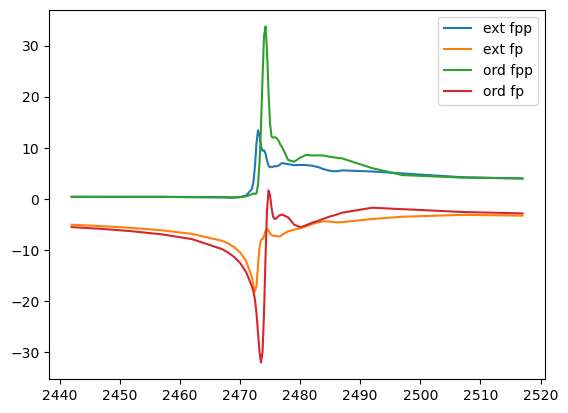

In [141]:
fpfpp_arr = np.hstack((mol_ordext_f1f2_DS.energy.values.reshape(45,1), mol_ordext_f1f2_DS.to_pandas().to_numpy()))[:, :]
fpfpp_arr[:,2] = fpfpp_arr[:,2] - 16
fpfpp_arr[:,4] = fpfpp_arr[:,4] - 16

plt.plot(fpfpp_arr[:,0], fpfpp_arr[:,1], label='ext fpp')
plt.plot(fpfpp_arr[:,0], fpfpp_arr[:,2], label='ext fp')
plt.plot(fpfpp_arr[:,0], fpfpp_arr[:,3], label='ord fpp')
plt.plot(fpfpp_arr[:,0], fpfpp_arr[:,4], label='ord fp')
plt.legend()
plt.show()

# fpfpp_arr

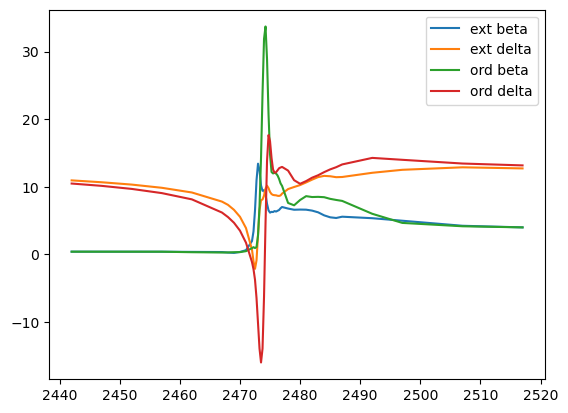

In [142]:
deltabeta_arr = np.hstack((mol_ordext_f1f2_DS.energy.values.reshape(45,1), mol_ordext_f1f2_DS.to_pandas().to_numpy()))[:, :]

plt.plot(deltabeta_arr[:,0], deltabeta_arr[:,1], label='ext beta')
plt.plot(deltabeta_arr[:,0], deltabeta_arr[:,2], label='ext delta')
plt.plot(deltabeta_arr[:,0], deltabeta_arr[:,3], label='ord beta')
plt.plot(deltabeta_arr[:,0], deltabeta_arr[:,4], label='ord delta')
plt.legend()
plt.show()

# fpfpp_arr

In [144]:
moldeltabetaZarrsPath.parent

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/trexs_nexafs_2024C3/waxs_all')

In [145]:
np.savetxt(moldeltabetaZarrsPath.parent.joinpath('PM6_S-edge_betadelta.txt'), deltabeta_arr)
np.savetxt(moldeltabetaZarrsPath.parent.joinpath('PM6_S-edge_fppfp.txt'), fpfpp_arr)

In [ ]:
moldeltabetaZarrsPath.exists()

In [ ]:
mol_ordext_deltabeta_DS.to_zarr(moldeltabetaZarrsPath.parent.joinpath('PM6_5CN-CF_all_deltabeta_176-S-diam_v1.zarr'), mode='w')

## Fitting lamella peak intensity profile

### Load experimental lamella peak intensity data

In [9]:
# Initalize dictionaries for sample names (for titles & saving files)
sn = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7 CF + 0.0% CN',
    'SiN-2': 'PM7 CF + 5.0% CN',
    'SiN-3': 'PM6 CF + 0.0% CN',
    'SiN-4': 'PM6 CF + 5.0% CN',
    'SiN-5': 'PM7 CF + 1.0% CN',
    'SiN-6': 'PM7 CF + 0.5% CN',
    'SiN-7': 'PM6 CF + 1.0% CN',
    'SiN-8': 'PM6 CF + 0.5% CN',    
}

sn_id = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7_CF',
    'SiN-2': 'PM7_5CN-CF',
    'SiN-3': 'PM6_CF',
    'SiN-4': 'PM6_5CN-CF',
    'SiN-5': 'PM7_1CN-CF',
    'SiN-6': 'PM7_p5CN-CF',
    'SiN-7': 'PM6_1CN-CF',
    'SiN-8': 'PM6_p5CN-CF',
}

In [10]:
# Define path to zarr
lpZarrPath = sorted(lpZarrsPath.glob('*.zarr'))[1]
lpZarrPath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/trexs_nexafs_2024C3/waxs_normal/lamella_vs_energy_zarrs/lamella_vs_energy_v2.zarr')

In [11]:
# Load zarr into xarray
polymer = 'PM6'
lp_DA = xr.open_zarr(lpZarrPath)['SiN-4_Full'].compute().sel(energy=slice(None,2520))
# lp_DA = xr.open_zarr(lpZarrPath)['SiN-2_Full'].compute().sel(energy=slice(None,2520))
lp_DA

<xarray.DataArray 'SiN-4_Full' (energy: 45)> Size: 360B
array([4.54547931e-05, 4.31507509e-05, 3.99017885e-05, 3.75432936e-05,
       3.34613186e-05, 2.83163090e-05, 2.56542010e-05, 2.32887496e-05,
       2.04584264e-05, 1.75654754e-05, 1.29222293e-05, 1.16864622e-05,
       1.03215084e-05, 8.89171182e-06, 8.71435584e-06, 9.83704757e-06,
       1.63924122e-05, 3.26778520e-05, 5.33381638e-05, 7.15564741e-05,
       7.67823793e-05, 7.10847003e-05, 6.13540316e-05, 5.24565683e-05,
       4.95899898e-05, 4.83987464e-05, 4.87349409e-05, 4.70874988e-05,
       4.62705132e-05, 4.49537735e-05, 4.52606949e-05, 3.96338347e-05,
       3.56662107e-05, 3.56499710e-05, 3.64419557e-05, 3.74885214e-05,
       3.94758818e-05, 3.94684381e-05, 3.99552432e-05, 4.02114787e-05,
       4.05404543e-05, 4.29221742e-05, 4.02522444e-05, 3.73020267e-05,
       3.45600778e-05])
Coordinates:
  * energy   (energy) float64 360B 2.442e+03 2.447e+03 ... 2.507e+03 2.517e+03
    theta    int64 8B 90
Attributes:
    chi_region:  Full
    chi_slice:   [-105, 15]

### Fit experimental data to generic resonance equation 4

In [17]:
def peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf):
    """
    Equation 4 from Freychet et al. 2021, "Resonant Tender X‐ray Diffraction for Disclosing the Molecular Packing of Paracrystalline Conjugated Polymer Films"
                    DOI: 10.1021/jacs.0c10721

    Inputs:
        F_0 (float): nonresonant energy-independent coefficient
        F_res (float): resonant energy-independent coefficient
        delta_phi (float): energy-independent phase change, in degrees
        f_0 (float): energy-independent atomic scattering factor term, approximated by atomic number Z
        real_asf (np array): real part of energy-dependent atomic scattering factor (from Kramers-Kronig calculations)
        imag_asf (np array): imaginary part of energy-dependent atomic scatterign factor (from NEXAFS)

    Returns:
        Equation 4 output
    """

    return (np.abs(F_0)**2 + 
            ((real_asf**2 + imag_asf**2)/(f_0**2))*np.abs(F_res)**2 + 
            2*(real_asf/f_0)*np.abs(F_0)*np.abs(F_res)*np.cos(np.deg2rad(delta_phi)) +
            2*(imag_asf/f_0)*np.abs(F_0)*np.abs(F_res)*np.sin(np.deg2rad(delta_phi)))


def peak_intensity_fit_residual(params, f_0, real_asf, imag_asf, peak_areas):
    """
    Inputs:
        params (list of floats): parameters to fit, [scaling_constant, F_0, F_res, delta_phi]
        f_0 (float): energy-independent atomic scattering factor term, approximated by atomic number Z
        real_asf (np array): real part of energy-dependent atomic scattering factor (from Kramers-Kronig calculations)
        imag_asf (np array): imaginary part of energy-dependent atomic scatterign factor (from NEXAFS)
        peak_areas (np array): experimental peak intensities to fit to

    Outputs:
        summed difference to minimize
    """
    constant = params[0]
    F_0 = params[1]
    F_res = params[2]
    delta_phi = params[3]
    
    # return np.mean(((peak_areas - (constant * peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf)))**2)).sum()
    return ((peak_areas - (constant * peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf)))**2).sum()


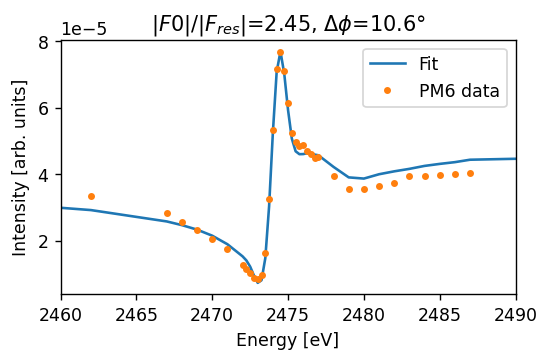

In [20]:
# e_slice = slice(2450, 2500)
e_slice = slice(None, None)
# e_slice = slice(2470, 2480)

# Fit general equation
peak_areas = lp_DA.sel(energy=e_slice).data.copy()
# peak_areas = scaled_intensity.copy()

S_f0 = 16
bnds = [(1e-10, 1e-1), (0.01, 1e2), (1,1), (0, 180)]
# res = optimize.differential_evolution(
#     peak_intensity_fit_residual, bounds=bnds, args=(f0, np.real(f_dict['S'])-f0, np.imag(f_dict['S']), peak_areas), tol=1e-10
# )

res = optimize.differential_evolution(
    peak_intensity_fit_residual, bounds=bnds, args=(
        S_f0, 
        mol_ordext_f1f2_DS['S_ordinary_f1'].data[:] - S_f0, 
        mol_ordext_f1f2_DS['S_ordinary_f2'].data[:],
        peak_areas), tol=1e-12
)

# print(res.x)

const = res.x[0]
F_0 = res.x[1]
F_res = res.x[2]
delta_phi = res.x[3]

output = peak_intensity_fit(F_0, 
                            F_res, 
                            delta_phi, 
                            S_f0, 
                            mol_ordext_f1f2_DS['S_ordinary_f1'].data[:] - S_f0, 
                            mol_ordext_f1f2_DS['S_ordinary_f2'].data[:])
    
fig, ax = plt.subplots(figsize=(4.5,3), dpi=125, tight_layout=True)

ax.plot(lp_DA.sel(energy=e_slice).energy.values, (const*output), label='Fit')
# ax.plot(lp_DA.sel(energy=e_slice).energy.values, peak_areas, label=f'{name}_structure', linestyle='--')
ax.plot(lp_DA.sel(energy=e_slice).energy.values, peak_areas, label=f'PM6 data', linestyle='', marker='.')
ax.set_title('$|F0|/|F_{res}|$'+f'={np.round(F_0,2)}, $\\Delta\\phi$={np.round(delta_phi,2)}°')
ax.set(xlabel='Energy [eV]', ylabel='Intensity [arb. units]')
ax.set_xlim(2460, 2490)
ax.legend()

# savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/lamella_vs_energy_fits_v1')
# savePath.mkdir(exist_ok=True)
# fig.savefig(savePath.joinpath(f'{polymer}_fit_F0-ratio-{np.round(F_0, 2)}_delta-phi-{np.round(delta_phi, 2)}-deg_energy{e_slice.start}-{e_slice.stop}.png'), dpi=125)

plt.show()

### Load sulfur atomic positions from MD cells

In [36]:
def strip_numbers(element):
        match = re.match(r"([a-zA-Z]+)", element)
        return match.group(1) if match else element
    
def load_xyz(xyz_path):
    """
    Loads the atomic symbols and coordinates from an XYZ file.

    Parameters:
    - xyz_path: string, path to xyz file of molecule, NP, etc.

    Returns:
    - coords: 2D numpy array of x, y, z coordinates.
    - elements: 1D numpy array of element species for each coord in coords.
    """
    # Extracting the atomic symbols and positions from the XYZ file
    with open(xyz_path, 'r') as file:
        lines = file.readlines()
    symbols = []
    coords = []
    for line in lines[2:]:  # Skipping the first two lines (header and comment)
        parts = line.split()
        if len(parts) < 4:
            # Skip lines that do not have at least 4 parts (symbol + 3 coordinates)
            print(f"Skipping line due to insufficient parts: {line.strip()}")
            continue
        try:
            symbol = strip_numbers(parts[0])
            x, y, z = map(float, parts[1:4])
            symbols.append(symbol)
            coords.append([x, y, z])
        except ValueError as e:
            # Skip lines where conversion to float fails or any other issue arises
            print(f"Skipping line due to error: {line.strip()} ({e})")
            continue
    # Convert lists to numpy arrays
    coords = np.array(coords)
    elements = np.array(symbols)
    
    return coords, elements

def load_pdb(pdb_path):
    """
    Parameters:
    - pdb_path: string, path to pdb file of molecule, protein, etc.

    Returns:
    - coords: 2D numpy array of x, y, z coordinates
    - elements: 1D numpy array of element species for each coord in coords
    """
    coords = []
    elements = []

    # Open and read the PDB file
    with open(pdb_path, 'r') as file:
        for line in file:
            if line.startswith("CRYST1"):
                x = float(line.split()[1])
                y = float(line.split()[2])
                z = float(line.split()[3])
                box_size = (x, y, z)                
            elif line.startswith("ATOM") or line.startswith("HETATM"):
                # Extracting the relevant information from ATOM/HETATM lines
                element = line[76:78].strip()  # Element symbol, typically in columns 77-78
                x = float(line[30:38])  # X coordinate, typically in columns 31-38
                y = float(line[38:46])  # Y coordinate, typically in columns 39-46
                z = float(line[46:54])  # Z coordinate, typically in columns 47-54

                elements.append(element)
                coords.append([x, y, z])

    coords = np.array(coords)
    elements = np.array(elements)
    
    return box_size, coords, elements

### Calculate lamella peak intensity profiles for various MD cells

In [ ]:
# %matplotlib widget
# plt.close('all')

# stoich = stoichiometry('F')

# plt.plot(asp_db_im(stoich).energies, asp_db_im(stoich).asf, label='fpp')
# plt.plot(asp_db_re(stoich).energies, asp_db_re(stoich).asf, label='fp')
# plt.xlim(2450, 2550)
# plt.show()

In [ ]:
e_slice

In [85]:
# energies = lp_DA.sel(energy=e_slice).energy.values
energies = lp_DA.energy.values

In [22]:
energies.shape

(45,)

In [ ]:
mol_ordext_f1f2_DS

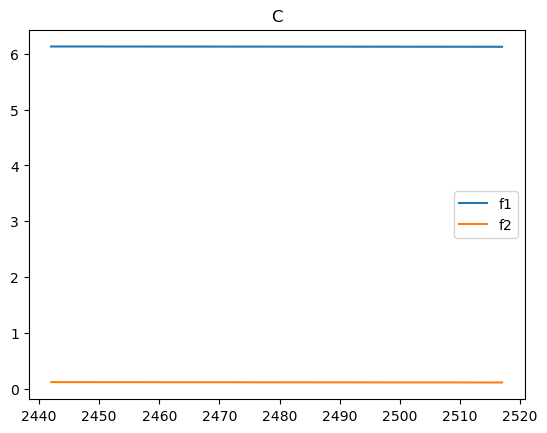

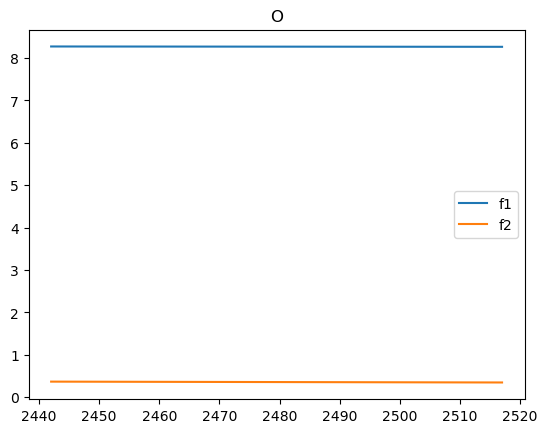

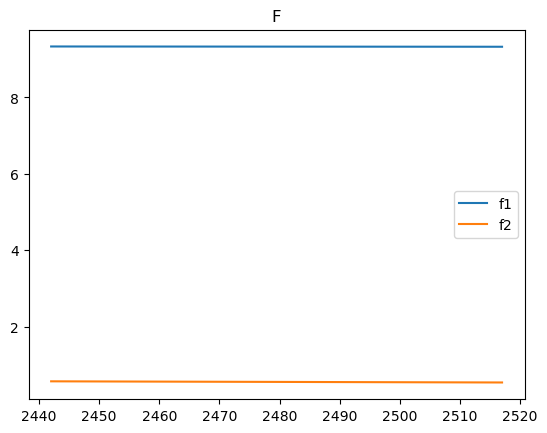

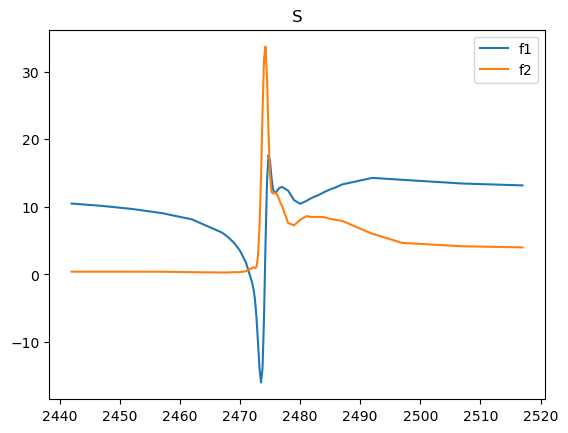

In [86]:
f_dict = {
    'C': mol_ordext_f1f2_DS['C_f1'].data + 1j*mol_ordext_f1f2_DS['C_f2'].data,
    'O': mol_ordext_f1f2_DS['O_f1'].data + 1j*mol_ordext_f1f2_DS['O_f2'].data,
    'F': mol_ordext_f1f2_DS['F_f1'].data + 1j*mol_ordext_f1f2_DS['F_f2'].data,
    'S': mol_ordext_f1f2_DS['S_ordinary_f1'].data + 1j*mol_ordext_f1f2_DS['S_ordinary_f2'].data
}

# Quick double check of henke factors:
for element in f_dict.keys():
    plt.plot(energies, np.real(f_dict[element]), label='f1')
    plt.plot(energies, np.imag(f_dict[element]), label='f2')
    plt.title(f'{element}')
    plt.legend()
    plt.show()
    plt.close('all')

In [83]:
# Functions to fit scaling factor of MD calculation to line up best with data

def peak_intensity_calc_residual(params, calc_areas, peak_areas):
    """
    Inputs:
        params (list of floats): parameters to fit, [scaling_constant]

    Outputs:
        summed difference to minimize
    """
    constant = params[0]
    
    # return np.mean(((peak_areas - (constant * peak_intensity_fit(F_0, F_res, delta_phi, f_0, real_asf, imag_asf)))**2)).sum()
    return ((peak_areas - (constant * calc_areas))**2).sum()

In [37]:
initialMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/initial')
initial_allMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/initial_all')
equilibratedMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/equilibrated')
decamerMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/decamer')
xyzMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/PM6_xyz')

In [ ]:
# sorted([f.name for f in initialMDPath.iterdir()])
# sorted([f.name for f in xyzMDPath.iterdir()])

#### Weak attempt at backing out f1,f2 from data

In [62]:
def intensity_calculation(f1, f2, elements, coords):
    atoms = []    
    for element, coord in zip(elements, coords):
        atom = (f1 + 1j*f2) * np.exp(2*np.pi*1j*np.dot(np.array([2,0,0]),coord)) # Calculate structure factor for individual atom
        atoms.append(atom)  # Append value array to atoms list

    # Calculate summed structure factor and intensity 
    structure_factor = np.array(atoms).sum(axis=0)  # Sums along atoms
    intensity = np.abs(structure_factor)**2  # Calculate norm squared for intensity

    return intensity

def intensity_calculation_by_energy_residual(params, elements, coords, data_intensity, scale_factor):
    f1 = params[0]
    f2 = params[1]
    return (data_intensity - (scale_factor*intensity_calculation(f1, f2, elements, coords)))**2

In [31]:
float(lp_DA.sel(energy=energy, method='nearest'))

4.315075094384671e-05

In [55]:
data_intensity

5.333816382167062e-05

In [57]:
intensity_calculation(f1, f2, elements, coords) * 5e-14

5.274216137453321e-05

In [77]:
lp_DA.energy.values

array([2442.  , 2447.  , 2452.  , 2457.  , 2462.  , 2467.  , 2468.  ,
       2469.  , 2470.  , 2471.  , 2472.  , 2472.25, 2472.5 , 2472.75,
       2473.  , 2473.25, 2473.5 , 2473.75, 2474.  , 2474.25, 2474.5 ,
       2474.75, 2475.  , 2475.25, 2475.5 , 2475.75, 2476.  , 2476.25,
       2476.5 , 2476.75, 2477.  , 2478.  , 2479.  , 2480.  , 2481.  ,
       2482.  , 2483.  , 2484.  , 2485.  , 2486.  , 2487.  , 2492.  ,
       2497.  , 2507.  , 2517.  ])

In [89]:
energies = np.array([2472.  , 2472.5 ,
                     2473.  , 2473.5 , 2473.75, 2474.  , 2474.25, 2474.5 ,
                     2475.  , 2475.5 ,  2476.])

In [98]:
# energy = 2473

scale_factor = 5e-14

# f1 = float(mol_ordext_f1f2_DS['S_ordinary_f1'].sel(energy=energy, method='nearest'))
# f2 = float(mol_ordext_f1f2_DS['S_ordinary_f2'].sel(energy=energy, method='nearest'))
f1s = []
f2s = []
intensities = []

energies = np.array([2472.  , 2472.5 ,
                     2473.  , 2473.5 , 2473.75, 2474.  , 2474.25, 2474.5 ,
                     2475.  , 2475.5 ,  2476.])

# for energy in tqdm(lp_DA.sel(energy=slice(2468, 2478)).energy.values):
for energy in tqdm(energies):
    data_intensity = float(lp_DA.sel(energy=energy, method='nearest'))

    if energy < 2470:
        bnds = [(-20, 12), (0, 2)]
    else: 
        bnds = [(-20, 12), (0, 40)]        
    res = optimize.differential_evolution(
        intensity_calculation_by_energy_residual, 
        bounds=bnds, 
        args=(elements, coords, data_intensity, scale_factor), 
        tol=1e-15
    )

    f1 = res.x[0]
    f2 = res.x[1]
    
    f1s.append(f1)
    f2s.append(f2)

    intensity = intensity_calculation(f1, f2, elements, coords)   
    intensities.append(intensity)
    


  0%|          | 0/11 [00:00<?, ?it/s]

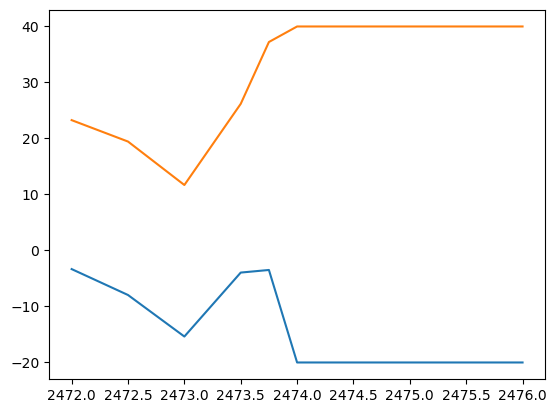

In [99]:
# energies = lp_DA.sel(energy=slice(2468, 2478)).energy.values

plt.plot(energies, np.array(f1s), label='f1')
plt.plot(energies, np.array(f2s), label='f2')
plt.show()

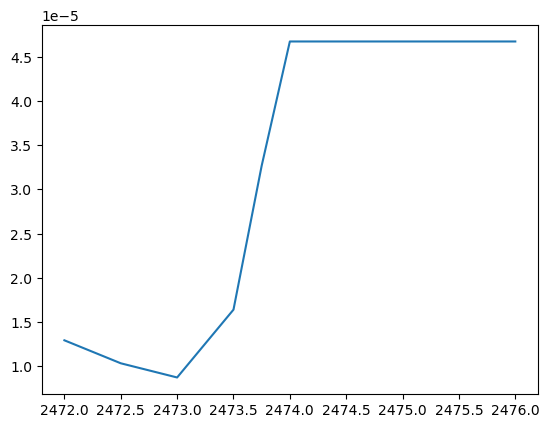

In [100]:
plt.plot(energies, np.array(intensities)*scale_factor, label='calculated intensity')
plt.show()

In [66]:
intensity_calculation_by_energy_residual([f1, f2], elements, coords, data_intensity, scale_factor)

9.910736924054844e-12

In [73]:
display(float(mol_ordext_f1f2_DS['S_ordinary_f1'].min()))
display(float(mol_ordext_f1f2_DS['S_ordinary_f1'].max()))
display(float(mol_ordext_f1f2_DS['S_ordinary_f2'].min()))
display(float(mol_ordext_f1f2_DS['S_ordinary_f2'].max()))

-15.976316903116688

17.6587328747367

0.2894596549325179

33.7224389667208

In [51]:
f2

31.894300940082758

In [88]:
MD_path

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/PM6_MD_sim/simulations/equilibrated/orthoEQ1000.pdb')

#### Back to regularly scheduled programming

JxEQ1000
Fractional minimums: (6.748245456181648e-05, 0.0004920614092638171, 0.0003990323465596376)
Fractional maximums: (0.9999325175454382, 0.9995079385907363, 0.9996009676534404)
1.3e-12
JxzEQ1000
Fractional minimums: (0.00025835149282227814, 0.00043682428743037187, 0.00044903457566234305)
Fractional maximums: (0.9997416485071777, 0.9995631757125697, 0.9995509654243376)
1.0e-12
JzEQ1000
Fractional minimums: (6.763154335174176e-05, 3.287599175908598e-05, 2.495072232335311e-05)
Fractional maximums: (0.9999323684566483, 0.999967124008241, 0.9999750492776767)
1.1e-12
aJxEQ1000
Fractional minimums: (4.494483022095877e-05, 9.83176753331914e-05, 2.494200982718235e-05)
Fractional maximums: (0.999955055169779, 0.9999016823246668, 0.9999750579901727)
1.0e-12
aJxzEQ1000
Fractional minimums: (2.2542323211857762e-05, 0.0005040764442885879, 9.982530571494343e-05)
Fractional maximums: (0.9999774576767883, 0.9994959235557115, 0.999900174694285)
1.0e-12
aJzEQ1000
Fractional minimums: (7.856870271845

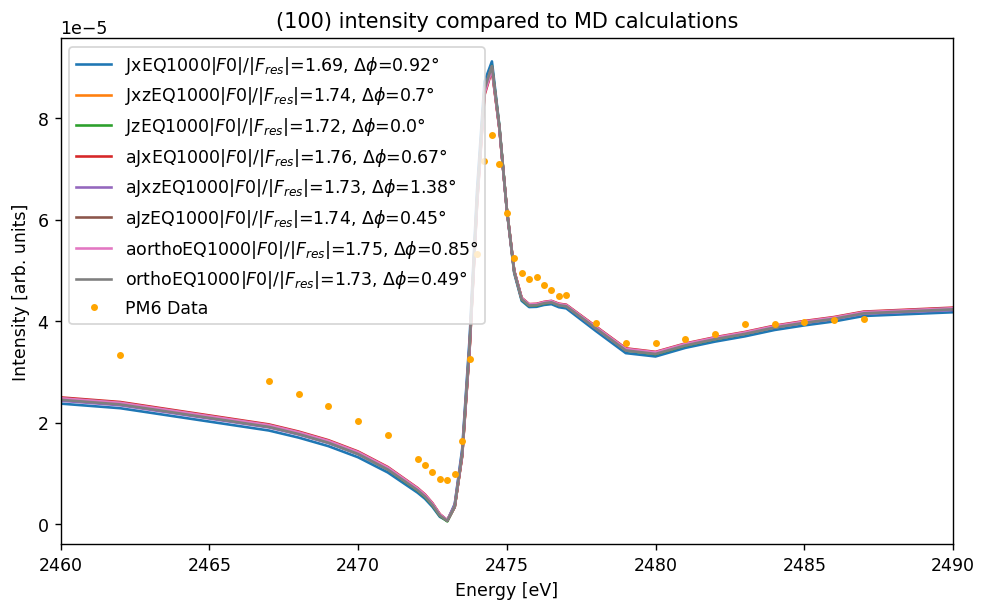

In [87]:
# Trimmed down cell, just pdbs, better plotting code
%matplotlib inline
plt.close('all')

polymer = 'PM6'

plot_xlims = (2460,2490)

# energy = lp_DA.sel(energy=e_slice).energy.values.copy()
energy = lp_DA.energy.values.copy()

fig, ax = plt.subplots(figsize=(8,5), dpi=125, tight_layout=True)
for MD_path in sorted(equilibratedMDPath.glob('*pdb')):
# for MD_path in sorted(initial_allMDPath.glob('*build*pdb')):

    if MD_path.suffix=='.pdb':
        print(MD_path.stem)
        box_size, coords, elements = load_pdb(str(MD_path))
    elif MD_path.suffix=='.xyz':
        print(MD_path.stem)
        coords, elements = load_xyz(str(MD_path))


    # Convert coordinates to fractional positions in MD crystal:
    # Identify minimum value and total distance value along dimensions (may be negative by default from pdb/xyz reading)
    x_shift = coords[:,0].min()  # minimum
    x_scalar = coords[:,0].max() - x_shift  # distance between max and min x
    y_shift = coords[:,1].min()
    y_scalar = coords[:,1].max() - y_shift
    z_shift = coords[:,2].min()
    z_scalar = coords[:,2].max() - z_shift

    # Shift and scale
    x_box_size = box_size[0]  # pdb box size in x
    y_box_size = box_size[1]  # pdb box size in y
    z_box_size = box_size[2]  # pdb box size in z
    coords[:,0] = ((coords[:,0]-x_shift) + (x_box_size-x_scalar)/2) / x_box_size
    coords[:,1] = ((coords[:,1]-y_shift) + (y_box_size-y_scalar)/2) / y_box_size
    coords[:,2] = ((coords[:,2]-z_shift) + (z_box_size-z_scalar)/2) / z_box_size

    # Print check (minimums should be close to zero, maximums should be close to one)
    print(f'Fractional minimums: {coords[:,0].min(), coords[:,1].min(), coords[:,2].min()}')
    print(f'Fractional maximums: {coords[:,0].max(), coords[:,1].max(), coords[:,2].max()}')
    
    atoms = []    
    for element, coord in zip(elements, coords):
        f = f_dict[element]  # Get atomic scattering factors for corresponding element
        atom = f * np.exp(2*np.pi*1j*np.dot(np.array([2,0,0]),coord)) # Calculate structure factor for individual atom
        atoms.append(atom)  # Append value array to atoms list

    # Calculate summed structure factor and intensity 
    structure_factor = np.array(atoms).sum(axis=0)  # Sums along atoms
    intensity = np.abs(structure_factor)**2  # Calculate norm squared for intensity

    # Scale and plot vs energy
    # bnds = [(1e-35, 1e-10)]
    bnds = [(1e-35, 1)]
    res = optimize.differential_evolution(
        peak_intensity_calc_residual, bounds=bnds, args=(intensity, lp_DA.data), tol=1e-13
    )
    scale_factor = res.x[0]
    scaled_intensity = intensity * scale_factor 

    # Get some string names for labelling plots
    # name = MD_path.stem.split('_')[0][:-6]
    # name = MD_path.stem.split('_')[0][:-3]
    name = MD_path.stem.split('_')[0][:]
    scale_factor_string = f'{scale_factor:.1e}'
    print(scale_factor_string)
    result_string = f'{res.fun:.1e}'

    # For each scaled_intensity fit value, also calculate the fit parameters from equation 4 in the earlier cell:
    # Fit scaled intensity to F0 / Delta_phi terms:
    S_f0 = 16
    
    bnds = [(1e-10, 1), (0.01, 1e2), (1,1), (0, 180)]
    res = optimize.differential_evolution(
        peak_intensity_fit_residual, bounds=bnds, args=(
            S_f0, 
            mol_ordext_f1f2_DS['S_ordinary_f1'].data[:] - S_f0, 
            mol_ordext_f1f2_DS['S_ordinary_f2'].data[:],
            scaled_intensity), tol=1e-12
    )
    
    const = res.x[0]
    F_0 = res.x[1]
    F_res = res.x[2]
    delta_phi = res.x[3] 

    # Plot scaled intensity
    ax.plot(energy, scaled_intensity, label=f'{name}'+'$|F0|/|F_{res}|$'+f'={np.round(F_0,2)}, $\\Delta\\phi$={np.round(delta_phi,2)}°')
    
    # print(res.x)   

ax.plot(energy, lp_DA.data, label=f'{polymer} Data', linestyle='', marker='.', color='orange')
ax.set_title(f'(100) intensity compared to MD calculations')
ax.set(xlabel='Energy [eV]', ylabel='Intensity [arb. units]')
ax.legend()
ax.set_xlim(plot_xlims)
plt.show()

# savePath = basePath.joinpath('trexs_plots/2024C3/waxs/lamella_vs_energy_calculations_v1')
# savePath.mkdir(exist_ok=True)
# fig.savefig(savePath.joinpath(f'{polymer}_calculation_MD-{name}_scale-factor-{scale_factor_string}_energy{e_slice.start}-{e_slice.stop}.png'), dpi=125)

plt.close('all')

In [ ]:
# # Original messy cell with everything from progressive working... 

# %matplotlib inline
# plt.close('all')

# polymer = 'PM6'

# # energy = lp_DA.sel(energy=e_slice).energy.values.copy()
# energy = lp_DA.energy.values.copy()

# # initialMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/initial')
# # equilibratedMDPath = basePath.joinpath('local_data/PM6_MD_sim/simulations/equilibrated')
# # decamerMDPath

# # for MD_path in sorted(initialMDPath.glob('*')):
# # for MD_path in sorted(equilibratedMDPath.glob('*')):
# # for MD_path in sorted(decamerMDPath.glob('*')):

# # x_dspacing = 20
# # for n in tqdm(range(1,6), desc='n'):
    
#     # for MD_path in tqdm(sorted(xyzMDPath.glob('*'))[:]):
#     # for group in ['init', 'eq1000', 'rlx']:
#     # for group in ['init']:

# # fig, ax = plt.subplots(figsize=(8,4), dpi=125, tight_layout=True)
# for MD_path in sorted(equilibratedMDPath.glob('*pdb')):
# # for MD_path in sorted(initial_allMDPath.glob('*RLX*pdb')):
#     # for MD_path in tqdm(sorted(xyzMDPath.glob(f'*{group}*'))[1:]):
# # for MD_path in sorted(xyzMDPath.glob('*rlx*'))[1:]:

#     if MD_path.suffix=='.pdb':
#         print(MD_path.stem)
#         coords, elements = load_pdb(str(MD_path))
#     elif MD_path.suffix=='.xyz':
#         print(MD_path.stem)
#         coords, elements = load_xyz(str(MD_path))

#     atoms = []

#     x_shift = coords[:,0].min()
#     x_scalar = coords[:,0].max() - x_shift
#     # y_shift = coords[:,1].min()
#     # y_scalar = coords[:,1].max() - x_shift
#     # z_shift = coords[:,2].min()
#     # z_scalar = coords[:,2].max() - x_shift

#     # coords[:,0] = (coords[:,0]-x_shift) / x_scalar
#     # coords[:,1] = (coords[:,1]-y_shift) / y_scalar
#     # coords[:,2] = (coords[:,2]-z_shift) / z_scalar

    
#     # coords[:,0] = ((coords[:,0]-x_shift) + (300-x_scalar)/2)  # / 300

    
#     coords[:,0] = ((coords[:,0]-x_shift) + (42-x_scalar)/2) / 42

    
#     # coords[:,0] = (coords[:,0]-x_shift + (42-x_scalar)*0) / 42
#     # coords[:,1] = (coords[:,1]-y_shift) + (42-y_scalar)
#     # coords[:,2] = (coords[:,2]-z_shift) + (39-z_scalar)

#     print(coords[:,0].min())
#     print(coords[:,0].max())
    
#     for element, coord in zip(elements, coords):
#         f = f_dict[element]
#         # print(coord[xyz])
        
#         # atom = f * np.exp(2*np.pi*1j*np.dot(np.array([21,0,0]),coord))
#         # atom = f * np.exp(2*np.pi*1j*np.dot(np.array([1/21,0,0]),coord))
#         # atom = f * np.exp(2*np.pi*1j*np.dot(np.array([2/21,0,1/19]),coord))
#         atom = f * np.exp(2*np.pi*1j*np.dot(np.array([2,0,0]),coord))
        
       
#         # # if coord[0]>x_dspacing*n and coord[0]<x_dspacing*(n+1) and coord[2]>19*n and coord[2]<19*(n+1):
#         # if coord[0]>x_dspacing*n and coord[0]<x_dspacing*(n+1):
#         #     # atom = f * np.exp(2*np.pi*1j*np.dot(np.array([1/x_dspacing,0,0.5/19]),coord-(21*n)))
#         #     atom = f * np.exp(2*np.pi*1j*np.dot(np.array([1,0,0]),(coord-(x_dspacing*n))/x_dspacing)) 
            
#         atoms.append(atom)
        
#     # print(atoms)
    
#     structure_factor = np.array(atoms).sum(axis=0)
#     intensity = np.abs(structure_factor)**2    

#     # Scale and plot vs energy
#     bnds = [(1e-35, 1)]
#     res = optimize.differential_evolution(
#         # peak_intensity_calc_residual, bounds=bnds, args=(intensity, lp_DA.sel(energy=e_slice).data), tol=1e-13
#         peak_intensity_calc_residual, bounds=bnds, args=(intensity, lp_DA.data), tol=1e-13
#     )
    
#     # print(res.x)
#     scale_factor = res.x[0]
#     # energy_idx = np.nonzero(lp_DA.energy.data==2474)[0][0]
#     # scale_factor = lp_DA.data[energy_idx] / intensity[energy_idx]
#     # print(scale_factor)
#     scaled_intensity = intensity * scale_factor 

#     name = MD_path.stem.split('_')[0]
#     print(name)
#     scale_factor_string = f'{scale_factor:.1e}'
#     result_string = f'{res.fun:.1e}'
    
#     fig, ax = plt.subplots(figsize=(8,4), dpi=125, tight_layout=True)
    
#     ax.plot(energy, scaled_intensity, label=f'{name} {scale_factor_string}')
#     # ax.legend()

    
#     # savePath = basePath.joinpath('trexs_plots/2024C3/waxs/lamella_vs_energy_calculations_v1')
#     # savePath.mkdir(exist_ok=True)
#     # fig.savefig(savePath.joinpath(f'{polymer}_calculation_MD-{name}_scale-factor-{scale_factor_string}_energy{e_slice.start}-{e_slice.stop}.png'), dpi=125)

#     # ax.plot(energy, lp_DA.sel(energy=e_slice).data, label=f'{polymer} Data', linestyle='', marker='.')
#     ax.plot(energy, lp_DA.data, label=f'{polymer} Data', linestyle='', marker='.')
#     # ax.set_title(f'Total lamella intensity, {name} MD calculation')
#     # ax.set_title(f'(100) intensity, n={n} MD calculation')
#     ax.set_title(f'(100) intensity + MD calculations')
#     ax.set(xlabel='Energy [eV]', ylabel='Intensity [arb. units]')
#     ax.legend()
#     plt.show()


#     # For each scaled_intensity fit value, also calculate the fit parameters from equation 4 in the earlier cell:

#     # Fit general equation
#     # peak_areas = lp_DA.sel(energy=e_slice).data.copy()
#     # peak_areas = scaled_intensity.copy()
    
#     bnds = [(1e-10, 1e-1), (0.01, 1e2), (1,1), (0, 360)]
#     res = optimize.differential_evolution(
#         peak_intensity_fit_residual, bounds=bnds, args=(f_0, np.real(f_dict['S'])-16, np.imag(f_dict['S']), scaled_intensity), tol=1e-10
#     )
    
#     # print(res.x)
    
#     const = res.x[0]
#     F_0 = res.x[1]
#     F_res = res.x[2]
#     delta_phi = res.x[3]
    
#     output = peak_intensity_fit(F_0, F_res, delta_phi, f_0, np.real(f_dict['S'])-16, np.imag(f_dict['S']))
        
#     fig, ax = plt.subplots(figsize=(4.5,3), dpi=125, tight_layout=True)
    
#     ax.plot(energy, (const*output), label='Fit')
#     ax.plot(energy, scaled_intensity, label=f'{name}_structure', linestyle='--')
#     ax.set_title(f'F0={np.round(F_0,3)}, delta_phi={np.round(delta_phi,3)}°')
#     ax.set(xlabel='Energy [eV]', ylabel='Intensity [arb. units]')
#     ax.legend()
    
#     # savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/lamella_vs_energy_fits_v1')
#     # savePath.mkdir(exist_ok=True)
#     # fig.savefig(savePath.joinpath(f'{polymer}_fit_F0-ratio-{np.round(F_0, 2)}_delta-phi-{np.round(delta_phi, 2)}-deg_energy{e_slice.start}-{e_slice.stop}.png'), dpi=125)
    
#     plt.show()

    
#     # plt.close('all')

## Scale & check agreement for various MD cell calculations

### Load cyrsoxs lamella peak intensity data

In [ ]:
# Define path to zarrs & zarr
cylpPaths = basePath.joinpath('local_data/trexs_nexafs_2024C3/cyrsoxs_lamella_vs_energy_zarrs')
cylpPaths_list = sorted(cylpPaths.glob('*.zarr'))

# lpZarrPath = sorted(lpZarrsPath.glob('*.zarr'))[1]
cylpZarrPath = sorted(cylpPaths.glob('*.zarr'))[1]
display(cylpZarrPath)
cylpZarrPath.exists()

In [ ]:
# Load zarr into xarray
cylp_DS = xr.open_zarr(cylpZarrPath)  #['SiN-4_Full'].compute().sel(energy=slice(None,2520))
cylp_DS

In [ ]:
%matplotlib widget
plt.close('all')

energy = cylp_DS.energy.values

for cylp_path in cylpPaths_list:
    # Load zarr into xarray
    cylp_DS = xr.open_zarr(cylp_path)  #['SiN-4_Full'].compute().sel(energy=slice(None,2520))
    # cylp_DS

      
    selected_DAs = [DA for DA in cylp_DS.data_vars.values() if 'Full' in DA.name]

    fig, ax = plt.subplots(figsize=(8,4), dpi=125, tight_layout=True)
    
    for cylp_DA in tqdm(selected_DAs):     
    
        intensity = cylp_DA.data.copy()
        
        # Scale and plot vs energy
        bnds = [(1e-10, 1)]
        res = optimize.differential_evolution(
            peak_intensity_calc_residual, bounds=bnds, args=(intensity, lp_DA.data[1:]), tol=1e-6
        )
        scale_factor = res.x[0]
    
        scale_factor_string = f'{scale_factor:.1e}'
        result_string = f'{res.fun:.1e}'
        
        scaled_intensity = intensity * scale_factor 
        
        # fig, ax = plt.subplots(figsize=(8,4), dpi=125, tight_layout=True)
        
        # ax.plot(energy, scaled_intensity, label=f'{name} {scale_factor_string}')
        ax.plot(energy, scaled_intensity, label=f'{cylp_DA.name.split('_')[1]} {scale_factor_string}')
        # ax.legend()
    
        
        # savePath = basePath.joinpath('trexs_plots/2024C3/waxs/lamella_vs_energy_calculations_v1')
        # savePath.mkdir(exist_ok=True)
        # fig.savefig(savePath.joinpath(f'{polymer}_calculation_MD-{name}_scale-factor-{scale_factor_string}_energy{e_slice.start}-{e_slice.stop}.png'), dpi=125)
    
    ax.plot(energy, lp_DA.data[1:], label=f'{polymer} Data', linestyle='', marker='.')
    ax.set_title(f'(100) data + {cylp_DA.name} CyRSoXS')
    ax.set(xlabel='Energy [eV]', ylabel='Intensity [arb. units]')
    ax.legend()
    plt.show()